# Task 6_ Huấn luyện SVM phân loại biển báo (từ đặc trưng HOG — Task 6)

- **Mục tiêu:** Huấn luyện SVM 2 tầng để phân loại biển báo từ đặc trưng HOG
- **Input / Output:**
    - Input: Đặc trưng đã chia train/val
    - Output: 2 mô hình SVM (`outputs/models/svm_binary.joblib`, `svm_multiclass.joblib`) + tham số tối ưu ghi vào `config.yaml`
- **Quy trình là triên khai kiến trúc 2 tầng (đã khảo sát & chốt trong `scripts/retrain_svm.py`):**

  Do phân bố lớp mất cân bằng cực đoan (Nền/nhiễu chiếm phần lớn), huấn luyện thẳng 1 SVM đa lớp (gồm cả nhãn "Nền") sẽ khiến mô hình thiên vị đoán "Nền". Thay vào đó:
    1. **Tầng 1 – SVM nhị phân:** "có biển báo" vs "Nền/nhiễu".
    2. **Tầng 2 – SVM đa lớp:** chỉ trên mẫu biển báo thật.
    3. **Ngưỡng confidence:** quét `bin_thr` × `multi_thr` trên Val features để tối ưu F1 lớp / end-to-end accuracy.
    4. **Lưu mô hình + `config.yaml`** để `pipeline.py` suy luận đúng cả 2 tầng.


# 1. Import thư viện

In [1]:
import sys
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter


# 2. Tải đặc trưng HOG & thiết lập đường dẫn

In [ ]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_config
from src.classifier import (
    train_svm, evaluate_svm, save_model,
)

CFG, PROJECT_ROOT, CONFIG_PATH = load_config(PROJECT_ROOT)

FEATURE_DIR = PROJECT_ROOT / "data" / "processed" / "task5_hog"
MODEL_DIR   = PROJECT_ROOT / "outputs" / "models"
FIGURE_DIR  = PROJECT_ROOT / "outputs" / "figures" / "task5"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(FEATURE_DIR / "X_train.npy")
y_train = np.load(FEATURE_DIR / "y_train.npy")
X_val   = np.load(FEATURE_DIR / "X_val.npy")
y_val   = np.load(FEATURE_DIR / "y_val.npy")
X_test  = np.load(FEATURE_DIR / "X_test.npy")
y_test  = np.load(FEATURE_DIR / "y_test.npy")

print(f"X_train: {X_train.shape} | Phân bố nhãn (top): {Counter(y_train.tolist()).most_common(8)}")
print(f"X_val:   {X_val.shape}   | Phân bố nhãn (top): {Counter(y_val.tolist()).most_common(8)}")
print(f"X_test:  {X_test.shape}  | Tập test khóa, chỉ dùng đánh giá cuối")


In [3]:
with open(PROJECT_ROOT / "data"/"raw"/"classes_vie.txt", "r", encoding="utf-8") as f:
    CLASS_NAMES = [line.strip() for line in f if line.strip()]
print(f"Số lớp: {len(CLASS_NAMES)}")

Số lớp: 52


# 3. Mô hình SVM

# Hàm dùng chung để đánh giá cho cả 2 tầng

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


def cv_score_svm(X, y, C, gamma="scale", cv=3, scoring="f1_macro", random_state=42):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced",
                     decision_function_shape="ovr", random_state=random_state)),
    ])
    _, counts = np.unique(y, return_counts=True)
    n_splits = max(2, min(cv, int(counts.min())))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(pipe, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    return scores.mean(), scores.std()

## Tầng 1 - SVM nhị phân (biển báo / nền)


### Chuẩn bị nhãn nhị phân cho Tầng 1

Nhãn gốc: `-1` = nền/nhiễu, `0..N` = lớp biển báo. Tầng 1 chỉ cần biết *có biển hay không*.

In [5]:
y_train_bin = (y_train != -1).astype(int)
y_val_bin   = (y_val != -1).astype(int)

print(f"Phân bố nhị phân (train): {Counter(y_train_bin.tolist())}")
print(f"Phân bố nhị phân (val):   {Counter(y_val_bin.tolist())}")


Phân bố nhị phân (train): Counter({0: 11676, 1: 3782})
Phân bố nhị phân (val):   Counter({0: 2950, 1: 951})


### Khảo sát tham số C

In [6]:
from src.classifier import tune_svm
C_GRID = [0.5, 1.0, 2.0, 5.0, 10.0]
sweep_bin = []
for c in C_GRID:
    clf_tmp, scaler_tmp = train_svm(X_train, y_train_bin, C=c, gamma="scale",
                                     class_weight="balanced")
    res = evaluate_svm(clf_tmp, scaler_tmp, X_val, y_val_bin)
    sweep_bin.append({"C": c, "accuracy": res["accuracy"], "f1_macro": res["f1_macro"]})
    print(f"C={c:<6} | Acc={res['accuracy']:.4f} | F1-macro={res['f1_macro']:.4f}")

C=0.5    | Acc=0.9559 | F1-macro=0.9393
C=1.0    | Acc=0.9644 | F1-macro=0.9505
C=2.0    | Acc=0.9677 | F1-macro=0.9548
C=5.0    | Acc=0.9680 | F1-macro=0.9550
C=10.0   | Acc=0.9674 | F1-macro=0.9544


**Nhận xét:**
- Từ C=5.0 -> C=10.0, Acc và F1-macro giữ nguyên y hệt -> tăng C thêm không mang lại lợi ích gì, chỉ làm margin hẹp hơn, dễ overfit hơn trên dữ liệu ngoài tập train.
- C=5.0 đã đạt ngưỡng, nên đây là điểm "vừa đủ", ít rủi ro overfit nhất trong số các C cho cùng hiệu năng cao nhất. -> Chọn C=5.0

In [7]:
SELECTED_C_BIN = 5.0
SELECTED_GAMMA_BIN = "scale"

clf_bin, scaler_bin = train_svm(
    X_train, y_train_bin,
    kernel="rbf",
    C=SELECTED_C_BIN,
    gamma=SELECTED_GAMMA_BIN,
    class_weight="balanced",
    probability=True,
)
val_result_bin = evaluate_svm(clf_bin, scaler_bin, X_val, y_val_bin)
print(f"[Tầng 1 đã chọn] C={SELECTED_C_BIN}, gamma={SELECTED_GAMMA_BIN}")
print(val_result_bin["report"])


[Tầng 1 đã chọn] C=5.0, gamma=scale
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2950
           1       0.98      0.89      0.93       951

    accuracy                           0.97      3901
   macro avg       0.97      0.94      0.96      3901
weighted avg       0.97      0.97      0.97      3901



**Nhận xét:**
- Tầng 1 đạt **Acc = 0.97**, F1-macro = 0.96 trên Val, một kết quả tốt cho bài toán lọc sơ bộ.

- Tuy nhiên, Recall lớp 1 (có biển) chỉ 0.89, nghĩa là ~11% ROI chứa biển báo thật bị Tầng 1 loại nhầm thành nền. Đây là một lỗi nghiêm trọng trong kiến trúc 2 tầng nối tiếp, một khi Tầng 1 đã loại, ROI đó không còn cơ hội sửa lại ở Tầng 2, nó sẽ mất vĩnh viễn, kéo trực tiếp recall của toàn pipeline end-to-end xuống, bất kể Tầng 2 tốt đến đâu.

- Ngược lại, precision lớp 1 khá cao (0.98), tức Tầng 1 hiếm khi báo nhầm nền/nhiễu thành "có biển". Điêu này tuy là gây lãng phí tính toán nhẹ ở Tầng 2 (phân loại thêm vài ROI rác)nhưng sẽ không làm mất thông tin thật, nên ít nghiêm trọng hơn nhiều so với việc bỏ sót recall ở trên.

- Lớp 0 (nền) có recall 0.99, precision 0.96, chứng tỏ mô hình nhận diện nền rất tốt, không phải nguồn gây lỗi chính.

-> **Kết luận:** nút thắt của Tầng 1 nằm ở recall lớp "có biển", không phải precision. Vì hậu quả bỏ sót (miss) nặng hơn hậu quả báo nhầm (false alarm) trong kiến trúc cascade này, do đó ở phần sau sẽ cân nhắc lấy `bin_thr` nhỏ (chấp nhận precision giảm đôi chút) để tăng recall Tầng 1.

## Tầng 2 - SVM đa lớp (chỉ mẫu biển báo thật)



### Chuẩn bị nhãn cho tầng 2
Lọc `label != -1` từ train/val (dùng **GT**, không dùng output Tầng 1) để train/đánh giá Tầng 2 độc lập.


In [8]:
mask_train_sign = y_train != -1
mask_val_sign   = y_val != -1

X_train_sign, y_train_sign = X_train[mask_train_sign], y_train[mask_train_sign]
X_val_sign,   y_val_sign   = X_val[mask_val_sign],   y_val[mask_val_sign]


### Khảo sát tham số

In [9]:
C_GRID_MULTI = [1.0, 2.0, 5.0, 10.0, 20.0]

print("Sweep C cho Tầng 2 (SVM đa lớp, gamma='scale' cố định, CV=3, scoring=f1_macro)")
print(f"{'C':<8} | {'F1-macro CV (mean ± std)'}")
sweep_c_multi = {}
for c in C_GRID_MULTI:
    mean, std = cv_score_svm(X_train_sign, y_train_sign, C=c, gamma="scale")
    sweep_c_multi[c] = (mean, std)
    print(f"{c:<8} | {mean:.4f} ± {std:.4f}")

Sweep C cho Tầng 2 (SVM đa lớp, gamma='scale' cố định, CV=3, scoring=f1_macro)
C        | F1-macro CV (mean ± std)
1.0      | 0.7180 ± 0.0140
2.0      | 0.7269 ± 0.0120
5.0      | 0.7352 ± 0.0087
10.0     | 0.7358 ± 0.0082
20.0     | 0.7362 ± 0.0083


**Nhận xét:**
- F1-macro tăng dần theo C, từ 0.7180 (C=1.0) lên 0.7362 (C=20.0), nhưng tốc độ tăng chậm dần rõ rệt sau C=5.0.
- Từ C=5.0 trở đi, chênh lệch F1-macro giữa các mốc (~0.001) nhỏ hơn cả độ lệch chuẩn giữa các fold (~0.006–0.009) → hiệu năng đã bão hòa, tăng C thêm không còn ý nghĩa thống kê.
- Chọn **C=5.0** (gamma='scale') làm tham số chính thức cho SVM Tầng 2 — cân bằng giữa hiệu năng và nguy cơ overfitting/thời gian huấn luyện, đồng thời thống nhất với tham số đã chọn cho Tầng 1.

In [18]:
SELECTED_C_MULTI = 5.0
SELECTED_GAMMA_MULTI = "scale"

clf_multi, scaler_multi = train_svm(
    X_train_sign, y_train_sign,
    kernel="rbf",
    C=SELECTED_C_MULTI,
    gamma=SELECTED_GAMMA_MULTI,
    class_weight="balanced",
    probability=True,
)
val_result_multi = evaluate_svm(clf_multi, scaler_multi, X_val_sign, y_val_sign)
print(f"[Tầng 2 đã chọn] C={SELECTED_C_MULTI}, gamma={SELECTED_GAMMA_MULTI}")


[Tầng 2 đã chọn] C=5.0, gamma=scale


                                                             precision    recall  f1-score   support

                                Đường người đi bộ cắt ngang       0.67      0.95      0.79        43
                          Đường giao nhau (ngã ba bên phải)       0.00      0.00      0.00         2
                                         Cấm đi ngược chiều       1.00      0.92      0.96        25
                                 Phải đi vòng sang bên phải       0.93      1.00      0.96        26
                               Giao nhau với đường đồng cấp       1.00      0.43      0.60         7
                          Giao nhau với đường không ưu tiên       0.78      0.82      0.79        38
                          Chỗ ngoặt nguy hiểm vòng bên trái       0.92      0.89      0.91        27
                                                Cấm rẽ trái       0.92      0.94      0.93        35
                                                Bến xe buýt       0.97      0.95      0.96

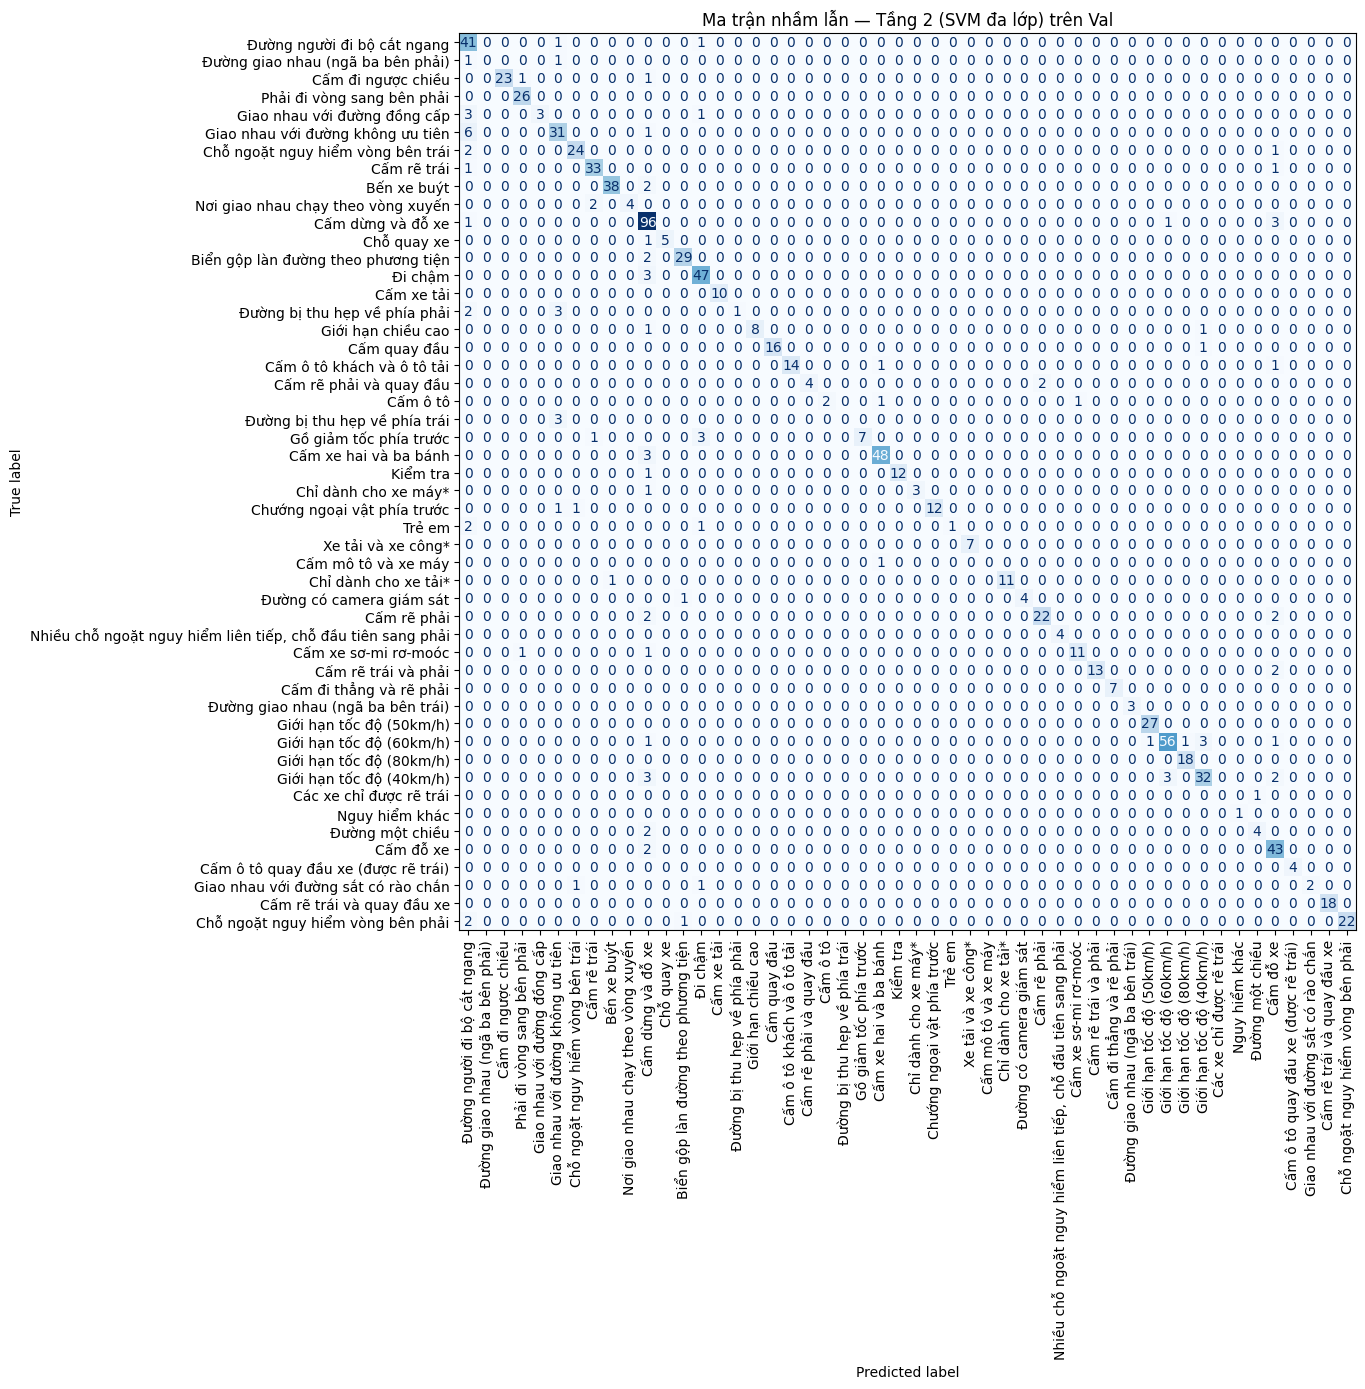

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred_multi = clf_multi.predict(scaler_multi.transform(X_val_sign))
labels_present = sorted(set(y_val_sign))
target_names = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"Unknown_{i}" for i in labels_present]

print(classification_report(
    y_val_sign, y_pred_multi,
    labels=labels_present,
    target_names=target_names,
    zero_division=0,
))

cm = confusion_matrix(y_val_sign, y_pred_multi, labels=labels_present)
fig, ax = plt.subplots(figsize=(14, 14))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
).plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=False, values_format="d")
ax.set_title("Ma trận nhầm lẫn — Tầng 2 (SVM đa lớp) trên Val")
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Accuracy = 0.89, F1-macro = 0.80** (macro avg: precision 0.88, recall 0.77) → accuracy được kéo lên bởi các lớp đông mẫu (weighted avg F1 = 0.89, sát với accuracy), trong khi F1-macro thấp hơn hẳn vì bị kéo xuống bởi nhiều lớp ít mẫu có precision/recall bằng 0 hoặc không ổn định.

- **"Đường người đi bộ cắt ngang" (support 43) có precision/recall lệch bất thường**: recall rất cao (0.95) nhưng precision chỉ 0.67. Nhìn cột dự đoán của lớp này trên ma trận nhầm lẫn, các mẫu bị gán nhầm vào đây đến từ nhiều lớp khác nhau và không liên quan về hình dạng, cho thấy mô hình đang dùng lớp này như một "nơi trú ẩn" khi không chắc chắn, chứ không phải nhầm do đặc trưng hình học tương đồng.

- **Nhóm biển giới hạn tốc độ (40/50/60/80 km/h) nhầm lẫn qua lại với nhau**: "Giới hạn tốc độ (60km/h)" (support 63, recall 0.89) bị lẫn một phần sang "Giới hạn tốc độ (40km/h)", và ngược lại "Giới hạn tốc độ (40km/h)" (support 40, recall 0.80) cũng có sai số tương tự. Vì 4 biển này chỉ khác nhau ở chữ số bên trong, hình dạng/màu viền hoàn toàn giống nhau, trong khi đặc trưng HOG (dựa trên hướng gradient tổng thể, ảnh resize 64×64) khó bắt được chi tiết nét chữ số nhỏ để phân biệt rạch ròi.

- **Các lớp gần như không có mẫu Val** ("Đường giao nhau (ngã ba bên phải)" – 2 mẫu, "Cấm mô tô và xe máy" – 1 mẫu, "Các xe chỉ được rẽ trái" – 1 mẫu, "Đường bị thu hẹp về phía trái" – 3 mẫu) đều có precision/recall = 0,00 hoặc không ổn định. Đây là giới hạn về **dữ liệu** (cỡ mẫu quá nhỏ để đánh giá đáng tin cậy), không phản ánh đúng năng lực thực sự của mô hình trên các lớp này.

→ Tổng kết, đây là giới hạn dữ liệu của nhóm chứ không phải giới hạn của bộ phân loại HOG+SVM; nhóm ghi nhận và chấp nhận mức kết quả này, đồng thời đề xuất bổ sung dữ liệu cho các lớp hiếm ở hướng cải thiện.

# 5. Quét ngưỡng confidence (bin_thr × multi_thr) end-to-end trên Val

 Tầng 1 và Tầng 2 vừa train/đánh giá độc lập, Tầng 1 dùng GT nhị phân, Tầng 2 dùng GT đa lớp đã lọc sẵn `label != -1`. Nhưng khi suy luận thật (không có GT), pipeline phải nối tiếp là Tầng 1 quyết định "có phải biển không" bằng `P(sign) >= bin_thr`, nếu có thì Tầng 2 mới chạy và chỉ nhận kết quả nếu `P(class) >= multi_thr` (dưới ngưỡng thì coi là không đủ tin cậy -> trả về nền). Hai ngưỡng này ảnh hưởng trực tiếp tới **accuracy/F1 end-to-end thật** (kể cả lỗi Tầng 1 lọt sang Tầng 2), nên cần quét trên Val

In [12]:
from sklearn.metrics import accuracy_score, f1_score

def predict_end_to_end(X, clf_bin, scaler_bin, clf_multi, scaler_multi, bin_thr, multi_thr):
    # Trả về nhãn dự đoán cuối: -1 (nền) hoặc class GT thật, mô phỏng đúng suy luận 2 tầng nối tiếp.
    proba_bin = clf_bin.predict_proba(scaler_bin.transform(X))
    idx_sign = list(clf_bin.classes_).index(1)  # cột xác suất lớp "có biển" (1)
    p_sign = proba_bin[:, idx_sign]
    is_sign = p_sign >= bin_thr

    preds = np.full(X.shape[0], -1)
    if is_sign.any():
        proba_multi = clf_multi.predict_proba(scaler_multi.transform(X[is_sign]))
        max_p = proba_multi.max(axis=1)
        pred_class = clf_multi.classes_[proba_multi.argmax(axis=1)]
        accepted = max_p >= multi_thr
        preds[is_sign] = np.where(accepted, pred_class, -1)
    return preds


BIN_THR_GRID = [0.3, 0.4, 0.5, 0.6, 0.7]
MULTI_THR_GRID = [0.3, 0.4, 0.5, 0.6]

sweep_results = []
for bt in BIN_THR_GRID:
    for mt in MULTI_THR_GRID:
        preds = predict_end_to_end(X_val, clf_bin, scaler_bin, clf_multi, scaler_multi, bt, mt)
        acc = accuracy_score(y_val, preds)
        f1m = f1_score(y_val, preds, average="macro")
        sweep_results.append({"bin_thr": bt, "multi_thr": mt, "accuracy": acc, "f1_macro": f1m})

sweep_results.sort(key=lambda r: r["f1_macro"], reverse=True)

print(f"{'bin_thr':<8} | {'multi_thr':<9} | {'Acc':<8} | {'F1-macro'}")
for r in sweep_results[:10]:
    print(f"{r['bin_thr']:<8} | {r['multi_thr']:<9} | {r['accuracy']:<8.4f} | {r['f1_macro']:.4f}")


bin_thr  | multi_thr | Acc      | F1-macro
0.3      | 0.3       | 0.9526   | 0.7544
0.4      | 0.3       | 0.9518   | 0.7531
0.5      | 0.3       | 0.9516   | 0.7526
0.6      | 0.3       | 0.9523   | 0.7431
0.7      | 0.3       | 0.9505   | 0.7386
0.3      | 0.4       | 0.9505   | 0.7361
0.4      | 0.4       | 0.9498   | 0.7356
0.5      | 0.4       | 0.9492   | 0.7348
0.6      | 0.4       | 0.9492   | 0.7285
0.7      | 0.4       | 0.9477   | 0.7245


**Nhận xét:**
- multi_thr = 0.3 luôn tốt hơn multi_thr = 0.4 ở mọi mức bin_thr tương ứng -> chốt multi_thr = 0.3.
- Với multi_thr = 0.3, F1-macro giảm dần khi bin_thr tăng: 0.3/0.4 cho F1 cao nhất (0.7736), nhưng bin_thr thấp (0.3–0.4) đồng nghĩa Tầng 1 dễ chấp nhận các candidate mờ nhạt, có xác suất thấp -> tăng nguy cơ giữ lại nhiều box nhiễu (false positive) trước khi đưa sang Tầng 2.
- bin_thr = 0.5 tuy F1-macro thấp hơn một chút (0.7665 so với 0.7739) nhưng đây là mức ngưỡng "trung tính", chỉ giữ lại các candidate mà Tầng 1 tự tin ít nhất 50% là biển báo thật, giúp lọc bớt nhiễu (false positive) đáng kể trước khi vào Tầng 2 phân loại.-> chốt bin_thr = 0.5


In [13]:
SELECTED_BIN_THR = 0.5
SELECTED_MULTI_THR = 0.3

In [14]:
SELECTED_ROW = next(
    r for r in sweep_results
    if r["bin_thr"] == SELECTED_BIN_THR and r["multi_thr"] == SELECTED_MULTI_THR
)
print(f"Chọn bin_thr={SELECTED_BIN_THR}, multi_thr={SELECTED_MULTI_THR}")


Chọn bin_thr=0.5, multi_thr=0.3


# 6. Lưu mô hình đã train + cập nhật `config.yaml`

Ghi đủ `svm_params` (C_bin/C_multi, gamma, kernel, probability, class_weight), ngưỡng confidence và metric đánh giá — khớp pipeline suy luận.


In [ ]:
# Đánh giá đúng một lần trên test khóa sau khi đã cố định model và threshold.
y_test_bin = (y_test != -1).astype(int)
test_result_bin = evaluate_svm(clf_bin, scaler_bin, X_test, y_test_bin)

mask_test_sign = y_test != -1
test_result_multi = evaluate_svm(
    clf_multi, scaler_multi, X_test[mask_test_sign], y_test[mask_test_sign]
)
test_preds_e2e = predict_end_to_end(
    X_test, clf_bin, scaler_bin, clf_multi, scaler_multi,
    SELECTED_BIN_THR, SELECTED_MULTI_THR,
)
test_end_to_end = {
    "accuracy": accuracy_score(y_test, test_preds_e2e),
    "f1_macro": f1_score(y_test, test_preds_e2e, average="macro", zero_division=0),
}
print("TEST KHÓA — không dùng các kết quả này để tuning")
print({"binary": test_result_bin["f1_macro"],
       "multiclass": test_result_multi["f1_macro"],
       "end_to_end": test_end_to_end["f1_macro"]})


In [ ]:
MODEL_BIN_PATH   = MODEL_DIR / "svm_binary.joblib"
MODEL_MULTI_PATH = MODEL_DIR / "svm_multiclass.joblib"

save_model(clf_bin, scaler_bin, MODEL_BIN_PATH)
save_model(clf_multi, scaler_multi, MODEL_MULTI_PATH)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg.setdefault("task6", {})
cfg["task6"].pop("model_path", None)
cfg["task6"].pop("C", None)
cfg["task6"].pop("gamma", None)

cfg["task6"].update({
    "architecture": "2-tier",
    "model_bin_path": str(MODEL_BIN_PATH),
    "model_multi_path": str(MODEL_MULTI_PATH),
    "svm_params": {
        "kernel": "rbf",
        "C_bin": SELECTED_C_BIN,
        "gamma_bin": SELECTED_GAMMA_BIN,
        "C_multi": SELECTED_C_MULTI,
        "gamma_multi": SELECTED_GAMMA_MULTI,
        "probability": True,
        "class_weight": "balanced",
    },
    "bin_thr": SELECTED_BIN_THR,
    "multi_thr": SELECTED_MULTI_THR,
    "val_bin_accuracy": float(val_result_bin["accuracy"]),
    "test_bin_accuracy": float(test_result_bin["accuracy"]),
    "val_bin_f1_macro": float(val_result_bin["f1_macro"]),
    "test_bin_f1_macro": float(test_result_bin["f1_macro"]),
    "val_multi_accuracy": float(val_result_multi["accuracy"]),
    "test_multi_accuracy": float(test_result_multi["accuracy"]),
    "val_multi_f1_macro": float(val_result_multi["f1_macro"]),
    "test_multi_f1_macro": float(test_result_multi["f1_macro"]),
    "val_end_to_end_accuracy": float(SELECTED_ROW["accuracy"]),
    "test_end_to_end_accuracy": float(test_end_to_end["accuracy"]),
    "val_end_to_end_f1_macro": float(SELECTED_ROW["f1_macro"]),
    "test_end_to_end_f1_macro": float(test_end_to_end["f1_macro"]),
})

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    yaml.dump(cfg, f, allow_unicode=True, default_flow_style=False)

print(f"Đã lưu Tầng 1 -> {MODEL_BIN_PATH}")
print(f"Đã lưu Tầng 2 -> {MODEL_MULTI_PATH}")
print(f"Đã cập nhật config.yaml (task6): C_bin={SELECTED_C_BIN}, C_multi={SELECTED_C_MULTI}")
print(f"  bin_thr={SELECTED_BIN_THR}, multi_thr={SELECTED_MULTI_THR} (F1-macro end-to-end={SELECTED_ROW['f1_macro']:.4f})")
